# Task 8: Spend-Quality Guardrail - Exploration

This notebook explores the dataset generated for evaluating the spend-quality guardrail. We'll examine the distributions of baseline scores vs prediction scores and look at the ground-truth outcomes.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/match_history.csv')
df.head()

,candidate_id,job_id,baseline_score,prediction_score,is_success
0,168,71,28.57,40.03,1
1,127,106,50.00,60.14,0
2,249,10,40.00,36.62,1
3,250,27,60.00,61.34,1
4,297,58,33.33,47.37,0


## Score Distribution
Let's look at the distribution of prediction scores for our candidate-job matches.

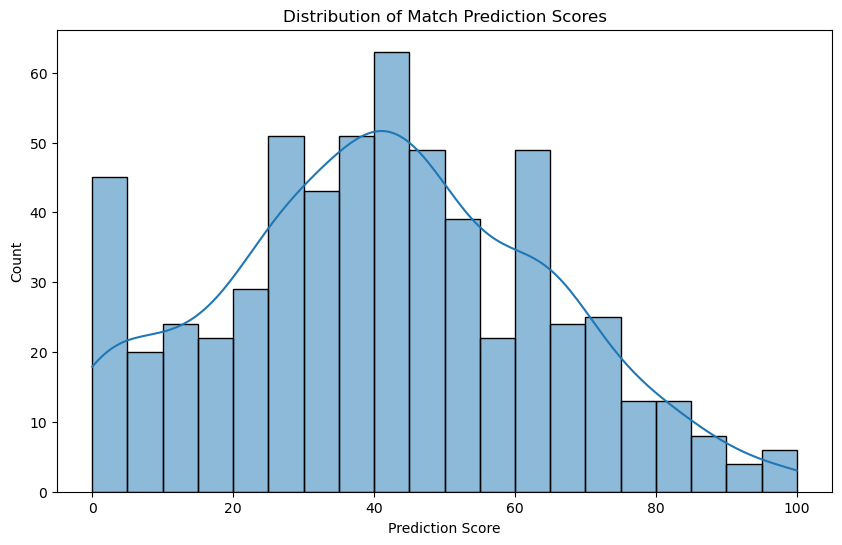

In [2]:
plt.figure(figsize=(10, 6))
sns.histplot(df['prediction_score'], bins=20, kde=True)
plt.title('Distribution of Match Prediction Scores')
plt.xlabel('Prediction Score')
plt.ylabel('Count')
plt.show()

## Success Rate by Score
We want to see how the actual success rate correlates with our model's prediction score.

C:\Users\rushi\AppData\Local\Temp\ipykernel_22552\1906357315.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  success_rates = df.groupby('score_bin')['is_success'].mean()


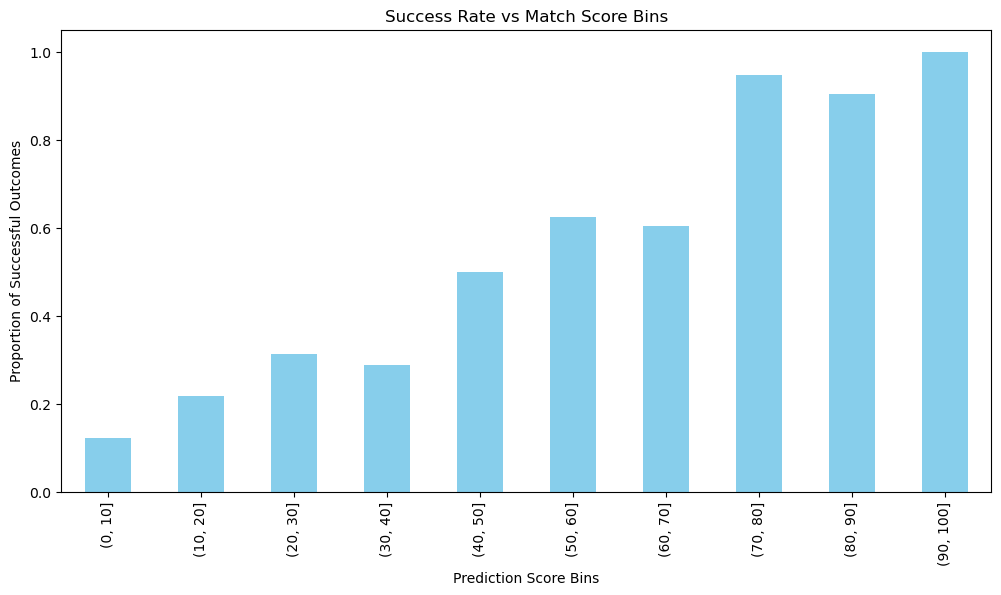

In [3]:
df['score_bin'] = pd.cut(df['prediction_score'], bins=range(0, 101, 10))
success_rates = df.groupby('score_bin')['is_success'].mean()

plt.figure(figsize=(12, 6))
success_rates.plot(kind='bar', color='skyblue')
plt.title('Success Rate vs Match Score Bins')
plt.xlabel('Prediction Score Bins')
plt.ylabel('Proportion of Successful Outcomes')
plt.show()

## Calibrating the Threshold
The baseline threshold can be calibrated using the F1 score and False Positive Rate metrics found in `src/threshold_calibration.py`. Our goal is to flag the matches on the left side of the histogram where success rates are near zero.